# 24AI636 DL — MASTER NOTEBOOK: Reviews 1–4
## NIH Chest X-Ray Complete Deep Learning Pipeline

Run this single notebook to execute the entire scaffolded project.
All 4 reviews in sequence, all models saved to `/kaggle/working/`.

| Review | Topic | Marks |
|--------|-------|-------|
| R1 | MLP + Custom CNN | 20 |
| R2 | Pretrained CNN + RNN/LSTM/GRU | 20 |
| R3 | Autoencoder + GAN | 20 |
| R4 | End-to-End System | 20 |
| **Total** | | **80** |


In [1]:
# ============================================================
# MASTER CONFIG — single place to change hyperparameters
# ============================================================
import os, sys, time, json, random, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')
try: import kagglehub
except: os.system('pip install kagglehub -q'); import kagglehub

SEED         = 42
IMG_SIZE_SM  = 64     # AE / GAN
IMG_SIZE     = 224    # CNN / R2 / R4
LATENT_DIM   = 128
BATCH_SIZE   = 32
SUBSET_FRAC  = 0.10   # Increase to 1.0 for full dataset
EPOCHS_R1    = 10
EPOCHS_R2    = 8
EPOCHS_R3_AE = 20
EPOCHS_R3_GAN= 30
EPOCHS_R4    = 10
LR           = 1e-4
WEIGHT_DECAY = 1e-5
NUM_WORKERS  = 2

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASSES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass',
           'Nodule','Pneumonia','Pneumothorax','Consolidation','Edema',
           'Emphysema','Fibrosis','Pleural_Thickening','Hernia']
NUM_CLASSES = len(CLASSES)

OUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
for sub in ['models_r1','models_r2','models_r3','models_r4','figures']:
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)
MODELS = {}  # global registry: name → checkpoint path

print(f'Device: {DEVICE} | Output: {OUT_DIR}')
print(f'Subset: {SUBSET_FRAC*100:.0f}% of NIH (~{int(112120*SUBSET_FRAC):,} images)')


Device: cuda | Output: /kaggle/working
Subset: 10% of NIH (~11,212 images)


## Shared Utilities (used across all reviews)


In [2]:
# ── Data loader ───────────────────────────────────────────────
def locate_data():
    if os.path.exists('/kaggle/input/data'): return '/kaggle/input/data'
    try: return kagglehub.dataset_download('nih-chest-xrays/data')
    except: return '.'

class NihDataset(Dataset):
    def __init__(self, df, data_dir, transform, grayscale=False):
        self.df, self.transform, self.gray = df, transform, grayscale
        self.paths = {}
        for root,_,files in os.walk(data_dir):
            for f in files:
                if f.endswith(('.png','.jpg')): self.paths[f] = os.path.join(root, f)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        p = self.paths.get(row['Image Index'])
        mode = 'L' if self.gray else 'RGB'
        try: img = Image.open(p).convert(mode) if p else Image.new(mode, (IMG_SIZE, IMG_SIZE))
        except: img = Image.new(mode, (IMG_SIZE, IMG_SIZE))
        return self.transform(img), torch.tensor(row[CLASSES].values.astype(np.float32))

def load_splits(data_path):
    csv = None
    for root,_,files in os.walk(data_path):
        if 'Data_Entry_2017.csv' in files: csv=os.path.join(root,'Data_Entry_2017.csv'); break
    df = pd.read_csv(csv)
    for lbl in CLASSES: df[lbl] = df['Finding Labels'].map(lambda x: 1.0 if lbl in x else 0.0)
    df = df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    tr, tmp = train_test_split(df, test_size=0.2, random_state=SEED)
    vl, te  = train_test_split(tmp, test_size=0.5, random_state=SEED)
    return tr.reset_index(drop=True), vl.reset_index(drop=True), te.reset_index(drop=True)

def make_loaders(tr, vl, te, dp, img_sz=IMG_SIZE, bs=BATCH_SIZE, gray=False, augment=True):
    norm_mean = [0.5] if gray else [0.485,0.456,0.406]
    norm_std  = [0.5] if gray else [0.229,0.224,0.225]
    tr_tf = transforms.Compose([
        transforms.Resize((img_sz, img_sz)),
        *([ transforms.RandomHorizontalFlip(), transforms.RandomRotation(10)] if augment else []),
        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
    vl_tf = transforms.Compose([
        transforms.Resize((img_sz, img_sz)),
        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
    mk = lambda d, tf, sh: DataLoader(NihDataset(d, dp, tf, gray), batch_size=bs, shuffle=sh, num_workers=NUM_WORKERS)
    pos_w = torch.tensor([(len(tr)-tr[c].sum())/max(tr[c].sum(),1) for c in CLASSES]).float().to(DEVICE)
    return mk(tr,tr_tf,True), mk(vl,vl_tf,False), mk(te,vl_tf,False), pos_w

# ── Training utils ────────────────────────────────────────────
def compute_auc(y_true, y_prob):
    try: return roc_auc_score(y_true, y_prob, average='macro')
    except: return 0.5

def save_model(model, name, review_dir, meta=None):
    path = os.path.join(OUT_DIR, review_dir, f'{name}.pth')
    ckpt = {'state_dict': model.state_dict(), 'classes': CLASSES,
            'model_class': type(model).__name__, 'meta': meta or {}}
    torch.save(ckpt, path); MODELS[name] = path
    # ONNX
    model.eval()
    ch = 1 if getattr(model,'grayscale',False) else 3
    sz = getattr(model,'img_size', IMG_SIZE)
    dummy = torch.randn(1, ch, sz, sz).to(DEVICE)
    try:
        torch.onnx.export(model, dummy, path.replace('.pth','.onnx'),
                          input_names=['image'], output_names=['logits'],
                          dynamic_axes={'image':{0:'b'},'logits':{0:'b'}}, opset_version=11)
    except: pass
    return path

def train_loop(model, tr_l, vl_l, name, review_dir, epochs, lr=LR, pos_w=None):
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt  = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=WEIGHT_DECAY)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
    best_auc, no_imp = 0, 0
    for ep in range(1, epochs+1):
        model.train(); tr_loss = 0
        for imgs, lbls in tr_l:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad(); loss = crit(model(imgs), lbls); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tr_loss += loss.item() * imgs.size(0)
        model.eval(); vl_loss, ay, ap = 0, [], []
        with torch.no_grad():
            for imgs, lbls in vl_l:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs); vl_loss += crit(out, lbls).item()*imgs.size(0)
                ay.append(lbls.cpu().numpy()); ap.append(torch.sigmoid(out).cpu().numpy())
        auc = compute_auc(np.concatenate(ay), np.concatenate(ap))
        hist['train_loss'].append(tr_loss/len(tr_l.dataset))
        hist['val_loss'].append(vl_loss/len(vl_l.dataset))
        hist['val_auc'].append(auc); sch.step()
        print(f'  [{name}] Ep{ep:02d} tr={hist["train_loss"][-1]:.4f} vl={hist["val_loss"][-1]:.4f} AUC={auc:.4f}')
        if auc > best_auc: best_auc=auc; no_imp=0; save_model(model, name, review_dir, {'auc':auc})
        else:
            no_imp += 1
            if no_imp >= 4: print(f'  Early stop'); break
    return hist, best_auc


---
# REVIEW 1 — MLP + Custom CNN


  REVIEW 1: MLP + CNN
Training MLP...
  [mlp_r1] Ep01 tr=1.3086 vl=1.1987 AUC=0.6249
  [mlp_r1] Ep02 tr=1.2837 vl=1.1970 AUC=0.6317
  [mlp_r1] Ep03 tr=1.2560 vl=1.2089 AUC=0.6150
  [mlp_r1] Ep04 tr=1.2526 vl=1.2190 AUC=0.6138
  [mlp_r1] Ep05 tr=1.2488 vl=1.2177 AUC=0.6220
  [mlp_r1] Ep06 tr=1.2440 vl=1.2228 AUC=0.6275
  Early stop
Training CNN...
  [cnn_r1] Ep01 tr=1.3249 vl=1.2014 AUC=0.6414
  [cnn_r1] Ep02 tr=1.2604 vl=1.2543 AUC=0.6085
  [cnn_r1] Ep03 tr=1.2467 vl=1.1985 AUC=0.6511
  [cnn_r1] Ep04 tr=1.2083 vl=1.2500 AUC=0.6347
  [cnn_r1] Ep05 tr=1.1820 vl=1.1860 AUC=0.6804
  [cnn_r1] Ep06 tr=1.1478 vl=1.1752 AUC=0.6696
  [cnn_r1] Ep07 tr=1.1171 vl=1.1759 AUC=0.6808
  [cnn_r1] Ep08 tr=1.1139 vl=1.1786 AUC=0.6842
  [cnn_r1] Ep09 tr=1.0968 vl=1.1680 AUC=0.6843
  [cnn_r1] Ep10 tr=1.0688 vl=1.1773 AUC=0.6835


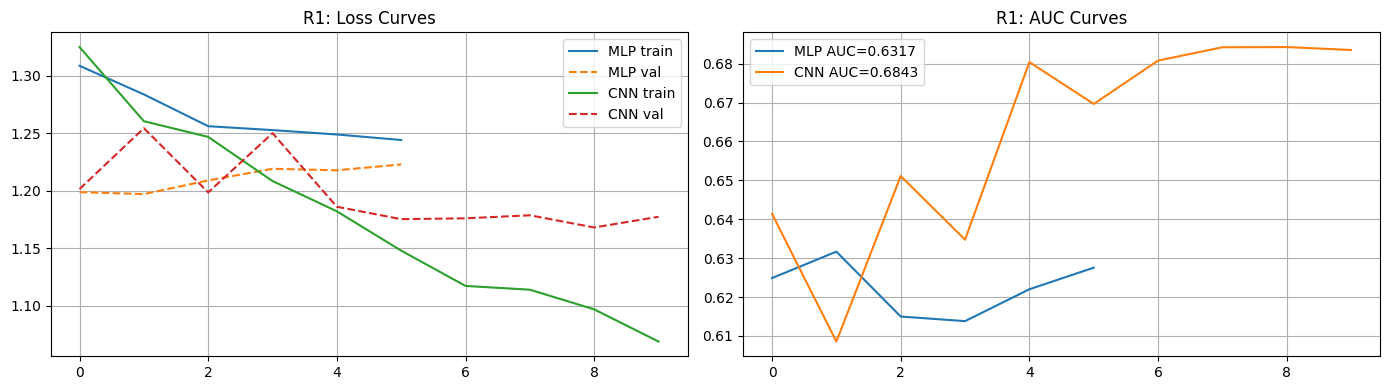

R1 complete | MLP AUC=0.6317 | CNN AUC=0.6843


In [3]:
print('='*60); print('  REVIEW 1: MLP + CNN'); print('='*60)

DATA_PATH = locate_data()
tr_df, vl_df, te_df = load_splits(DATA_PATH)
tr_l1, vl_l1, te_l1, pos_w1 = make_loaders(tr_df, vl_df, te_df, DATA_PATH)

class ChestMLP(nn.Module):
    def __init__(self, n=NUM_CLASSES, dr=0.4):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),
            nn.Linear(3*IMG_SIZE*IMG_SIZE,1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dr),
            nn.Linear(1024,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dr),
            nn.Linear(512,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Linear(256, n))
    def forward(self, x): return self.net(x)

class ConvBlock(nn.Module):
    def __init__(self, i, o): super().__init__(); self.b = nn.Sequential(
        nn.Conv2d(i,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True),
        nn.Conv2d(o,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True), nn.MaxPool2d(2,2))
    def forward(self, x): return self.b(x)

class ChestCNN(nn.Module):
    def __init__(self, n=NUM_CLASSES, dr=0.3):
        super().__init__()
        self.feats = nn.Sequential(ConvBlock(3,32),ConvBlock(32,64),ConvBlock(64,128),ConvBlock(128,256))
        self.pool  = nn.AdaptiveAvgPool2d((4,4))
        self.head  = nn.Sequential(nn.Flatten(), nn.Linear(256*16,512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Dropout(dr), nn.Linear(512,n))
    def forward(self, x): return self.head(self.pool(self.feats(x)))

mlp_model = ChestMLP().to(DEVICE)
cnn_model = ChestCNN().to(DEVICE)
r1_results = {}

print('Training MLP...')
mlp_hist, mlp_auc = train_loop(mlp_model, tr_l1, vl_l1, 'mlp_r1', 'models_r1', EPOCHS_R1, pos_w=pos_w1)
r1_results['MLP'] = {'auc': mlp_auc, 'hist': mlp_hist}

print('Training CNN...')
cnn_hist, cnn_auc = train_loop(cnn_model, tr_l1, vl_l1, 'cnn_r1', 'models_r1', EPOCHS_R1, pos_w=pos_w1)
r1_results['CNN'] = {'auc': cnn_auc, 'hist': cnn_hist}

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in r1_results.items():
    axes[0].plot(res['hist']['train_loss'], label=f'{name} train')
    axes[0].plot(res['hist']['val_loss'],   label=f'{name} val', linestyle='--')
    axes[1].plot(res['hist']['val_auc'],    label=f'{name} AUC={res["auc"]:.4f}')
axes[0].set_title('R1: Loss Curves'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('R1: AUC Curves'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'figures','r1_curves.png'),dpi=100); plt.show()
print(f'R1 complete | MLP AUC={mlp_auc:.4f} | CNN AUC={cnn_auc:.4f}')


---
# REVIEW 2 — Pretrained CNN + RNN/LSTM/GRU


  REVIEW 2: Pretrained CNN + Temporal Modeling

Training CNN+RNN...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


  [cnn_rnn_r2] Ep01 tr=1.3056 vl=1.1626 AUC=0.6853
  [cnn_rnn_r2] Ep02 tr=1.2222 vl=1.1581 AUC=0.6967
  [cnn_rnn_r2] Ep03 tr=1.1993 vl=1.1570 AUC=0.7061
  [cnn_rnn_r2] Ep04 tr=1.1681 vl=1.1851 AUC=0.7031
  [cnn_rnn_r2] Ep05 tr=1.1331 vl=1.1566 AUC=0.7214
  [cnn_rnn_r2] Ep06 tr=1.1024 vl=1.2207 AUC=0.7155
  [cnn_rnn_r2] Ep07 tr=1.0709 vl=1.1937 AUC=0.7149
  [cnn_rnn_r2] Ep08 tr=1.0358 vl=1.2110 AUC=0.7177

Training CNN+LSTM...
  [cnn_lstm_r2] Ep01 tr=1.3003 vl=1.1660 AUC=0.6475
  [cnn_lstm_r2] Ep02 tr=1.2631 vl=1.1593 AUC=0.6713
  [cnn_lstm_r2] Ep03 tr=1.2391 vl=1.1848 AUC=0.6677
  [cnn_lstm_r2] Ep04 tr=1.2356 vl=1.2193 AUC=0.6623
  [cnn_lstm_r2] Ep05 tr=1.1994 vl=1.2593 AUC=0.6912
  [cnn_lstm_r2] Ep06 tr=1.1637 vl=1.2350 AUC=0.6910
  [cnn_lstm_r2] Ep07 tr=1.1338 vl=1.2102 AUC=0.6978
  [cnn_lstm_r2] Ep08 tr=1.1045 vl=1.2219 AUC=0.6973

Training CNN+GRU...
  [cnn_gru_r2] Ep01 tr=1.2871 vl=1.1811 AUC=0.6657
  [cnn_gru_r2] Ep02 tr=1.2380 vl=1.1882 AUC=0.6946
  [cnn_gru_r2] Ep03 tr=1.1960 v

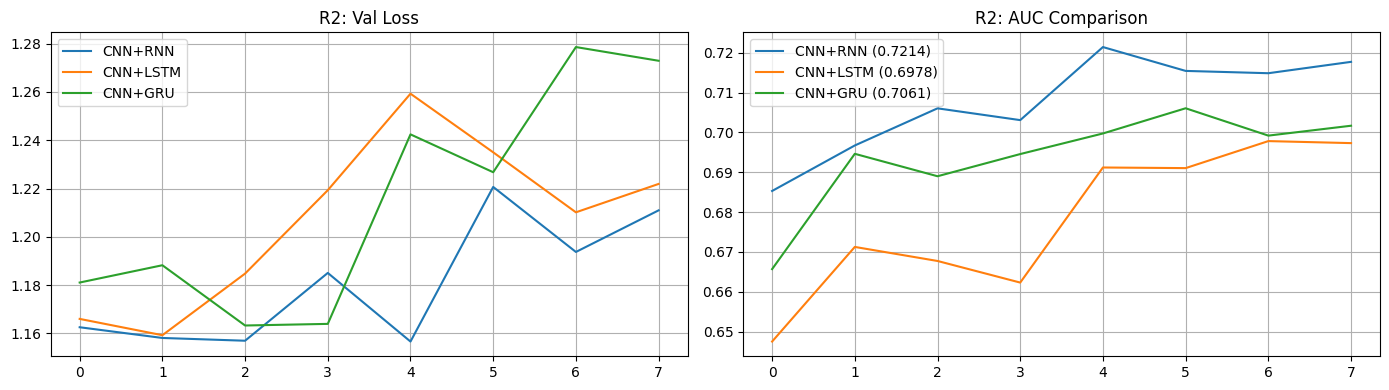


Best R2 model: CNN+RNN AUC=0.7214


In [4]:
print('='*60); print('  REVIEW 2: Pretrained CNN + Temporal Modeling'); print('='*60)

tr_l2, vl_l2, te_l2, pos_w2 = make_loaders(tr_df, vl_df, te_df, DATA_PATH)

# ── Spatial CNN-RNN hybrid ────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0,d,2).float() * (-np.log(10000)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class CNNRNNModel(nn.Module):
    def __init__(self, rnn_type='lstm', hidden=256, n_layers=2, bidir=True,
                 n_classes=NUM_CLASSES, backbone='resnet50', attention=True):
        super().__init__()
        self.rnn_type, self.attention = rnn_type, attention
        # Pretrained backbone
        if backbone == 'resnet50':
            base = models.resnet50(weights='IMAGENET1K_V1')
            for p in base.parameters(): p.requires_grad = False
            for p in base.layer4.parameters(): p.requires_grad = True
            self.backbone = nn.Sequential(*list(base.children())[:-2])  # 7x7 feature maps
            feat_dim = 2048
        elif backbone == 'densenet121':
            base = models.densenet121(weights='IMAGENET1K_V1')
            for p in base.parameters(): p.requires_grad = False
            for p in base.features.denseblock4.parameters(): p.requires_grad = True
            self.backbone = base.features
            feat_dim = 1024
        embed_dim = 256
        self.proj = nn.Linear(feat_dim, embed_dim)
        self.pe   = PositionalEncoding(embed_dim)
        rnn_cls = {'lstm': nn.LSTM, 'gru': nn.GRU, 'rnn': nn.RNN}[rnn_type]
        self.rnn = rnn_cls(embed_dim, hidden, n_layers, batch_first=True,
                           bidirectional=bidir, dropout=0.3 if n_layers>1 else 0)
        out_dim = hidden * (2 if bidir else 1)
        if attention:
            self.attn_fc = nn.Linear(out_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(out_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes))
    def forward(self, x):
        B = x.size(0)
        feats = F.relu(self.backbone(x))  # B x C x H x W
        feats = feats.view(B, feats.size(1), -1).permute(0,2,1)  # B x seq x C
        feats = self.pe(F.relu(self.proj(feats)))
        out, _ = self.rnn(feats)
        if self.attention:
            w = torch.softmax(self.attn_fc(out), dim=1)  # B x seq x 1
            ctx = (out * w).sum(dim=1)
        else:
            ctx = out[:, -1]
        return self.classifier(ctx)

# Train 3 model variants
r2_results = {}
for rnn_type in ['rnn', 'lstm', 'gru']:
    print(f'\nTraining CNN+{rnn_type.upper()}...')
    m = CNNRNNModel(rnn_type=rnn_type, hidden=256, bidir=True, backbone='resnet50').to(DEVICE)
    h, a = train_loop(m, tr_l2, vl_l2, f'cnn_{rnn_type}_r2', 'models_r2', EPOCHS_R2, pos_w=pos_w2)
    r2_results[f'CNN+{rnn_type.upper()}'] = {'model':m, 'auc':a, 'hist':h}

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in r2_results.items():
    axes[0].plot(res['hist']['val_loss'], label=name)
    axes[1].plot(res['hist']['val_auc'], label=f'{name} ({res["auc"]:.4f})')
axes[0].set_title('R2: Val Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('R2: AUC Comparison'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'figures','r2_comparison.png'),dpi=100); plt.show()

best_r2_name = max(r2_results, key=lambda n: r2_results[n]['auc'])
print(f'\nBest R2 model: {best_r2_name} AUC={r2_results[best_r2_name]["auc"]:.4f}')


---
# REVIEW 3 — Autoencoder + GAN


  REVIEW 3: Autoencoder + GAN
Training Autoencoder...
  AE ep05 loss=0.0145
  AE ep10 loss=0.0100
  AE ep15 loss=0.0086
  AE ep20 loss=0.0073
Training GAN...
  GAN ep10 G=1.3122 D=0.5430


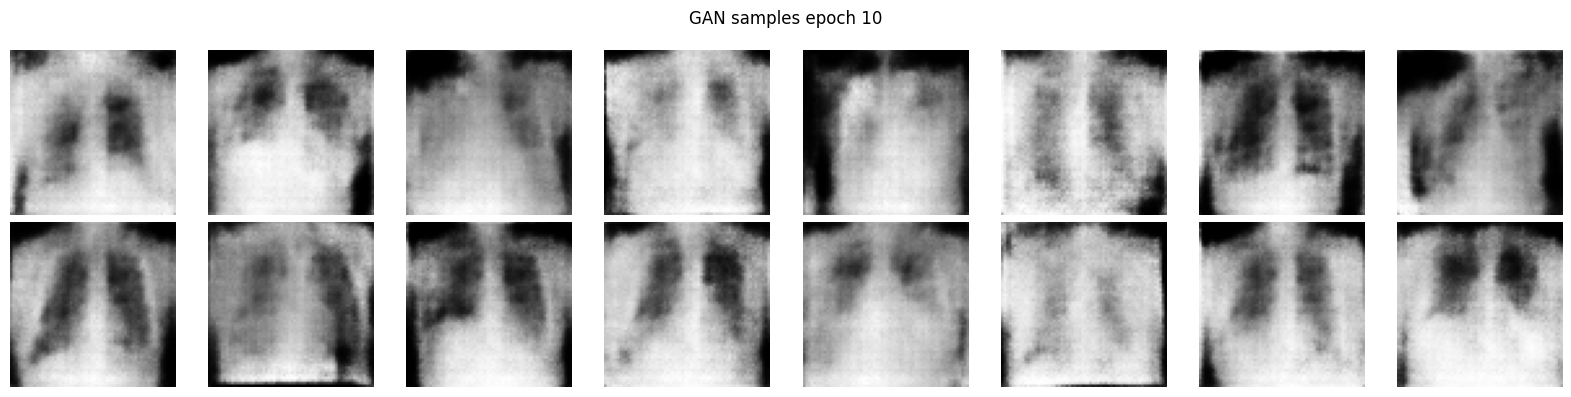

  GAN ep20 G=1.3656 D=0.5207


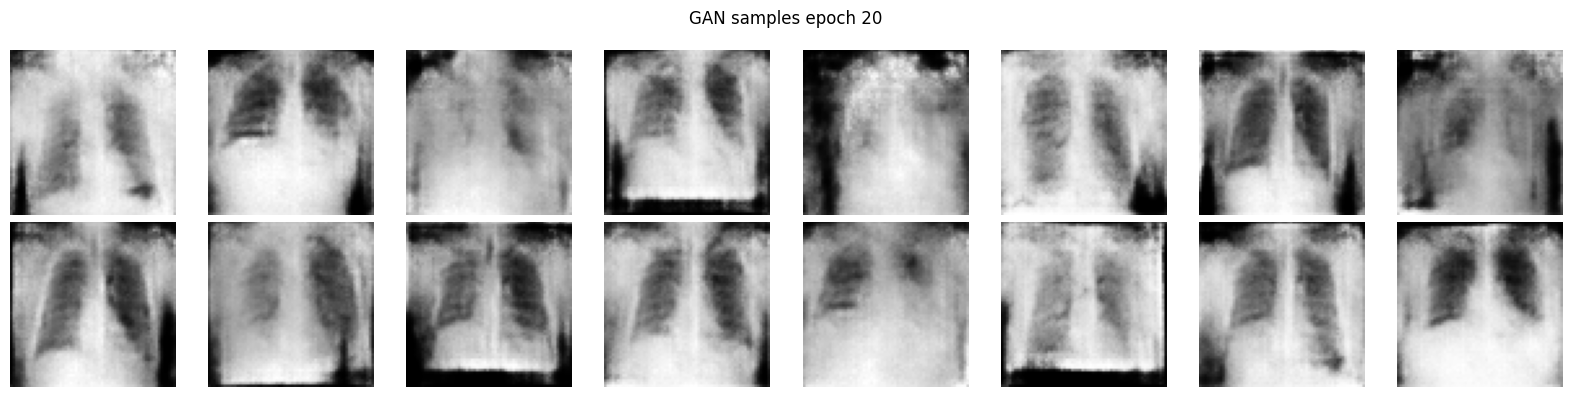

  GAN ep30 G=1.4050 D=0.5088


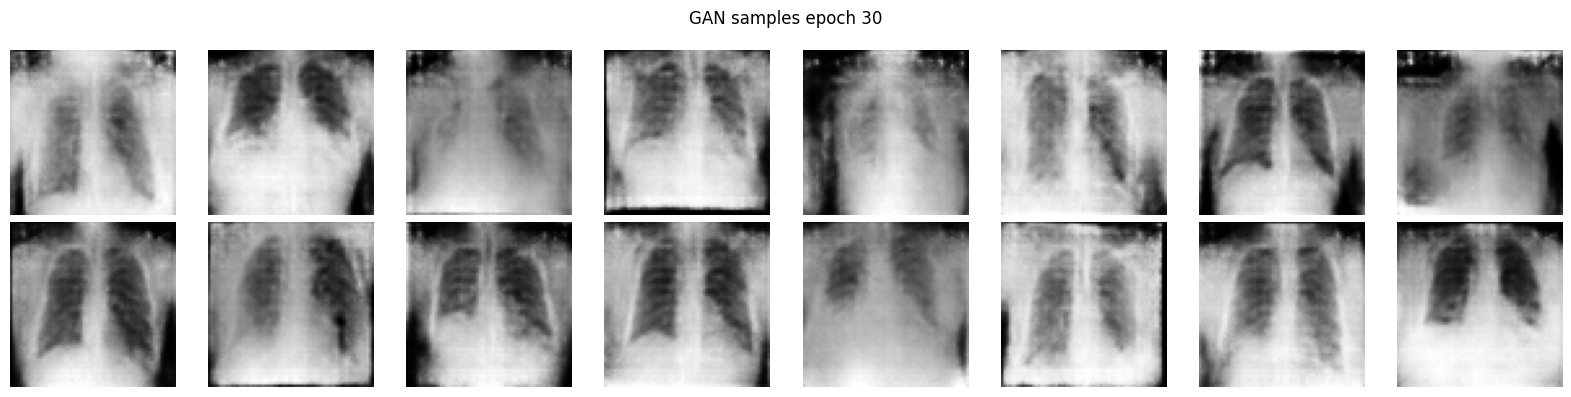

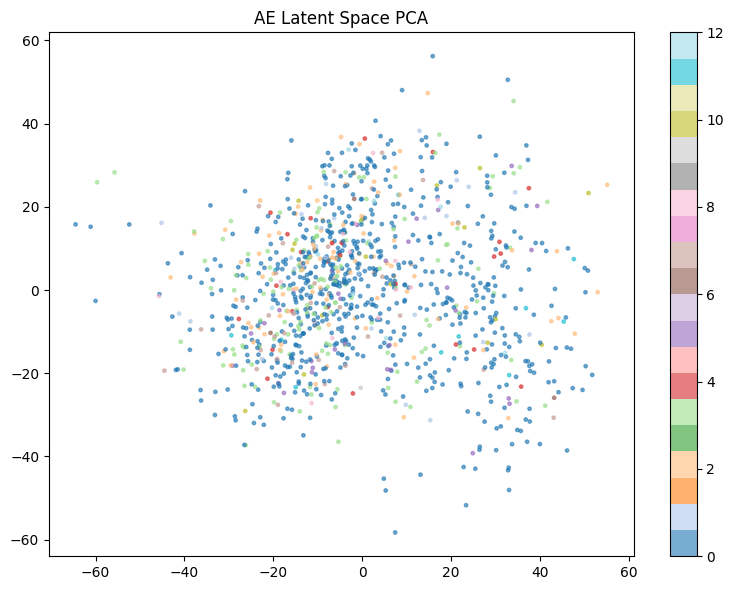

Review 3 complete


In [5]:
print('='*60); print('  REVIEW 3: Autoencoder + GAN'); print('='*60)

# Use 64x64 grayscale for generative models
tr_l3, vl_l3, te_l3, _ = make_loaders(tr_df, vl_df, te_df, DATA_PATH,
                                        img_sz=64, bs=64, gray=True, augment=False)

# ── Autoencoder ──────────────────────────────────────────────
class AE(nn.Module):
    def __init__(self, z=LATENT_DIM):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,32,4,2,1,bias=False), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32,64,4,2,1,bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1,bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1,bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2))
        self.fc_enc = nn.Linear(256*4*4, z)
        self.fc_dec = nn.Linear(z, 256*4*4)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1,bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1,bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1,bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1,bias=False), nn.Tanh())
        self.img_size, self.grayscale = 64, True
    def encode(self, x): return self.fc_enc(self.enc(x).view(x.size(0),-1))
    def decode(self, z): return self.dec(F.relu(self.fc_dec(z)).view(-1,256,4,4))
    def forward(self, x): z=self.encode(x); return self.decode(z), z

# ── Generator + Discriminator ────────────────────────────────
class G(nn.Module):
    def __init__(self, z=LATENT_DIM): super().__init__(); self.fc=nn.Linear(z,256*4*4); self.net=nn.Sequential(
        nn.ConvTranspose2d(256,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.ReLU(True),
        nn.ConvTranspose2d(128,64,4,2,1,bias=False),nn.BatchNorm2d(64),nn.ReLU(True),
        nn.ConvTranspose2d(64,32,4,2,1,bias=False),nn.BatchNorm2d(32),nn.ReLU(True),
        nn.ConvTranspose2d(32,1,4,2,1,bias=False),nn.Tanh())
    def forward(self,z): return self.net(F.relu(self.fc(z)).view(-1,256,4,4))

class D_net(nn.Module):
    def __init__(self): super().__init__(); SN=nn.utils.spectral_norm; self.net=nn.Sequential(
        SN(nn.Conv2d(1,32,4,2,1)),nn.LeakyReLU(0.2),
        SN(nn.Conv2d(32,64,4,2,1)),nn.BatchNorm2d(64),nn.LeakyReLU(0.2),
        SN(nn.Conv2d(64,128,4,2,1)),nn.BatchNorm2d(128),nn.LeakyReLU(0.2),
        SN(nn.Conv2d(128,256,4,2,1)),nn.BatchNorm2d(256),nn.LeakyReLU(0.2),
        nn.Flatten(), SN(nn.Linear(256*4*4,1)))
    def forward(self,x): return self.net(x)

ae  = AE().to(DEVICE)
gen = G().to(DEVICE)
dis = D_net().to(DEVICE)

# Train AE
ae_opt = optim.Adam(ae.parameters(), lr=1e-3)
ae_hist = {'loss':[]}
print('Training Autoencoder...')
for ep in range(1, EPOCHS_R3_AE+1):
    ae.train(); ep_l = 0
    for imgs, _ in tr_l3:
        imgs = imgs.to(DEVICE); ae_opt.zero_grad()
        rec, _ = ae(imgs); loss = F.mse_loss(rec, imgs); loss.backward(); ae_opt.step()
        ep_l += loss.item()
    ae_hist['loss'].append(ep_l/len(tr_l3))
    if ep%5==0: print(f'  AE ep{ep:02d} loss={ae_hist["loss"][-1]:.4f}')
save_model(ae, 'ae_r3', 'models_r3', {'type':'autoencoder'})

# Train GAN
g_opt = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5,0.999))
d_opt = optim.Adam(dis.parameters(), lr=2e-4, betas=(0.5,0.999))
bce = nn.BCEWithLogitsLoss()
gan_hist = {'G':[], 'D':[]}
fz = torch.randn(16, LATENT_DIM).to(DEVICE)
print('Training GAN...')
for ep in range(1, EPOCHS_R3_GAN+1):
    gen.train(); dis.train(); gl, dl = 0, 0
    for imgs, _ in tr_l3:
        bs = imgs.size(0); real = imgs.to(DEVICE)
        d_opt.zero_grad()
        rl = bce(dis(real), torch.ones(bs,1,device=DEVICE)*0.9)
        fl = bce(dis(gen(torch.randn(bs,LATENT_DIM,device=DEVICE)).detach()), torch.zeros(bs,1,device=DEVICE)+0.1)
        ((rl+fl)*0.5).backward(); d_opt.step()
        for _ in range(2):
            g_opt.zero_grad()
            gls = bce(dis(gen(torch.randn(bs,LATENT_DIM,device=DEVICE))), torch.ones(bs,1,device=DEVICE))
            gls.backward(); g_opt.step()
        gl += gls.item(); dl += (rl+fl).item()*0.5
    gan_hist['G'].append(gl/len(tr_l3)); gan_hist['D'].append(dl/len(tr_l3))
    if ep%10==0:
        print(f'  GAN ep{ep:02d} G={gan_hist["G"][-1]:.4f} D={gan_hist["D"][-1]:.4f}')
        gen.eval()
        with torch.no_grad(): samp = gen(fz).cpu()
        fig,axes=plt.subplots(2,8,figsize=(16,4))
        for i in range(16): axes[i//8,i%8].imshow(samp[i,0]*0.5+0.5, cmap='gray'); axes[i//8,i%8].axis('off')
        plt.suptitle(f'GAN samples epoch {ep}'); plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR,'figures',f'gan_ep{ep}.png'),dpi=80); plt.show()

torch.save({'G':gen.state_dict(),'D':dis.state_dict()}, os.path.join(OUT_DIR,'models_r3','gan_r3.pth'))
MODELS['gan_r3'] = os.path.join(OUT_DIR,'models_r3','gan_r3.pth')

# Latent PCA
ae.eval(); zs, ys = [], []
with torch.no_grad():
    for imgs, lbls in te_l3:
        zs.append(ae.encode(imgs.to(DEVICE)).cpu().numpy()); ys.append(lbls.numpy())
zs, ys = np.concatenate(zs), np.concatenate(ys)
pca = PCA(2, random_state=SEED).fit_transform(zs)
ci = np.argmax(ys, axis=1)
plt.figure(figsize=(8,6)); plt.scatter(pca[:,0],pca[:,1],c=ci,cmap='tab20',s=6,alpha=0.6)
plt.colorbar(); plt.title('AE Latent Space PCA')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'figures','r3_latent_pca.png'),dpi=100); plt.show()
print('Review 3 complete')


---
# REVIEW 4 — End-to-End System


In [6]:
print('='*60); print('  REVIEW 4: End-to-End DL System'); print('='*60)

tr_l4, vl_l4, te_l4, pos_w4 = make_loaders(tr_df, vl_df, te_df, DATA_PATH)

# DenseNet-121 production model
class DenseNetCXR(nn.Module):
    def __init__(self, n=NUM_CLASSES, dr=0.3):
        super().__init__()
        base = models.densenet121(weights='IMAGENET1K_V1')
        self.features = base.features
        for p in self.features.parameters(): p.requires_grad = False
        for p in self.features.denseblock4.parameters(): p.requires_grad = True
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dr), nn.Linear(1024,512),
                                    nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dr/2), nn.Linear(512,n))
    def forward(self, x): return self.head(self.pool(F.relu(self.features(x))))

densenet = DenseNetCXR().to(DEVICE)
print('Training DenseNet-121...')
dn_hist, dn_auc = train_loop(densenet, tr_l4, vl_l4, 'densenet121_r4', 'models_r4',
                              EPOCHS_R4, pos_w=pos_w4)

# Final evaluation
densenet.eval(); all_y, all_p = [], []
with torch.no_grad():
    for imgs, lbls in te_l4:
        all_p.append(torch.sigmoid(densenet(imgs.to(DEVICE))).cpu().numpy())
        all_y.append(lbls.numpy())
y, p = np.concatenate(all_y), np.concatenate(all_p)
per_class = {c: roc_auc_score(y[:,i],p[:,i]) for i,c in enumerate(CLASSES)
             if y[:,i].sum()>0 and (1-y[:,i]).sum()>0}
print(f'\nDenseNet-121 Test AUC = {np.mean(list(per_class.values())):.4f}')
print('Per-class AUC:')
for c, auc in sorted(per_class.items(), key=lambda x: -x[1]):
    print(f'  {c:<25} {auc:.4f}')
save_model(densenet, 'densenet121_prod', 'models_r4', {'per_class_auc': per_class})


  REVIEW 4: End-to-End DL System
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 168MB/s]


Training DenseNet-121...
  [densenet121_r4] Ep01 tr=1.2760 vl=1.1434 AUC=0.6940
  [densenet121_r4] Ep02 tr=1.1754 vl=1.1282 AUC=0.7141
  [densenet121_r4] Ep03 tr=1.1331 vl=1.1237 AUC=0.7216
  [densenet121_r4] Ep04 tr=1.0868 vl=1.0995 AUC=0.7307
  [densenet121_r4] Ep05 tr=1.0372 vl=1.0866 AUC=0.7414
  [densenet121_r4] Ep06 tr=1.0157 vl=1.1000 AUC=0.7396
  [densenet121_r4] Ep07 tr=0.9909 vl=1.0840 AUC=0.7441
  [densenet121_r4] Ep08 tr=0.9698 vl=1.0844 AUC=0.7441
  [densenet121_r4] Ep09 tr=0.9513 vl=1.0957 AUC=0.7440
  [densenet121_r4] Ep10 tr=0.9536 vl=1.0875 AUC=0.7439

DenseNet-121 Test AUC = 0.7387
Per-class AUC:
  Hernia                    0.9688
  Edema                     0.8559
  Effusion                  0.7938
  Fibrosis                  0.7878
  Pneumothorax              0.7759
  Cardiomegaly              0.7347
  Emphysema                 0.7221
  Atelectasis               0.7087
  Consolidation             0.7011
  Nodule                    0.6846
  Infiltration              

'/kaggle/working/models_r4/densenet121_prod.pth'

---
# Final Summary — All Reviews



  MASTER SUMMARY — ALL 4 REVIEWS COMPLETE
  R1 MLP AUC   = 0.6317
  R1 CNN AUC   = 0.6843
  R2 Best AUC  = 0.7214  (CNN+RNN)
  R3 AE Loss   = 0.0073  (reconstruction loss)
  R4 DenseNet  = 0.7441

  Saved Models:
    mlp_r1                         → /kaggle/working/models_r1/mlp_r1.pth
    cnn_r1                         → /kaggle/working/models_r1/cnn_r1.pth
    cnn_rnn_r2                     → /kaggle/working/models_r2/cnn_rnn_r2.pth
    cnn_lstm_r2                    → /kaggle/working/models_r2/cnn_lstm_r2.pth
    cnn_gru_r2                     → /kaggle/working/models_r2/cnn_gru_r2.pth
    ae_r3                          → /kaggle/working/models_r3/ae_r3.pth
    gan_r3                         → /kaggle/working/models_r3/gan_r3.pth
    densenet121_r4                 → /kaggle/working/models_r4/densenet121_r4.pth
    densenet121_prod               → /kaggle/working/models_r4/densenet121_prod.pth


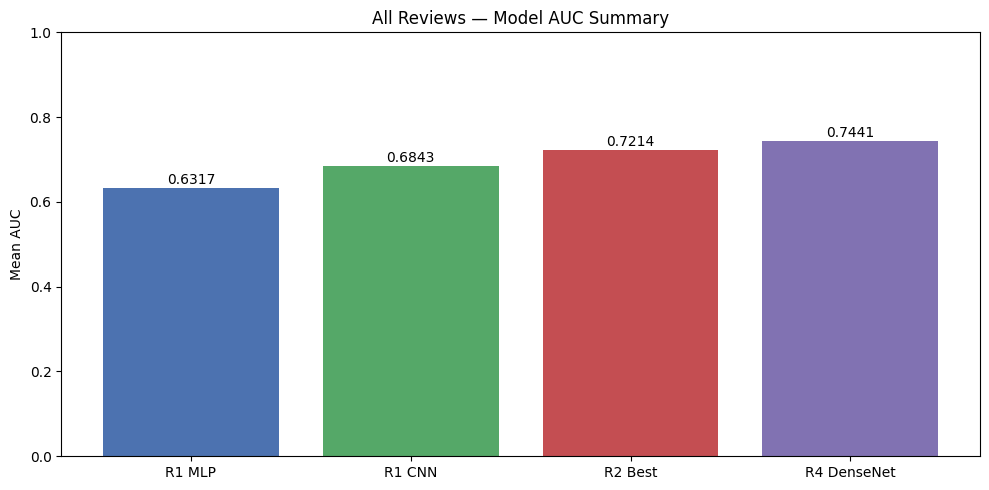


  All done! 🎓


In [7]:
print('\n' + '='*70)
print('  MASTER SUMMARY — ALL 4 REVIEWS COMPLETE')
print('='*70)

summary = {
    'R1 MLP':  r1_results['MLP']['auc'],
    'R1 CNN':  r1_results['CNN']['auc'],
    'R2 Best': max(r2_results[n]['auc'] for n in r2_results),
    'R3 AE':   float(ae_hist['loss'][-1]),  # loss (lower is better)
    'R4 DenseNet': dn_auc
}

print(f'  R1 MLP AUC   = {summary["R1 MLP"]:.4f}')
print(f'  R1 CNN AUC   = {summary["R1 CNN"]:.4f}')
print(f'  R2 Best AUC  = {summary["R2 Best"]:.4f}  ({best_r2_name})')
print(f'  R3 AE Loss   = {summary["R3 AE"]:.4f}  (reconstruction loss)')
print(f'  R4 DenseNet  = {summary["R4 DenseNet"]:.4f}')

print('\n  Saved Models:')
for name, path in MODELS.items():
    print(f'    {name:<30} → {path}')

# Save summary CSV
pd.DataFrame([{'model': k, 'metric': v} for k, v in summary.items()]).to_csv(
    os.path.join(OUT_DIR, 'master_summary.csv'), index=False)

# AUC bar chart
auc_items = {k:v for k,v in summary.items() if 'AE' not in k}
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(auc_items.keys(), auc_items.values(), color=['#4C72B0','#55A868','#C44E52','#8172B2'])
ax.set_ylim(0, 1); ax.set_ylabel('Mean AUC'); ax.set_title('All Reviews — Model AUC Summary')
for i,(k,v) in enumerate(auc_items.items()): ax.text(i, v+0.01, f'{v:.4f}', ha='center')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'figures','master_summary.png'),dpi=100); plt.show()

print('\n  All done! 🎓')
